# HPA Classification

In [1]:
import os
import subprocess
import re
import yaml
import requests
from datetime import datetime, timedelta
from pathlib import Path

import fastcore
from concurrent.futures import ThreadPoolExecutor, as_completed
from dotenv import dotenv_values
from ghapi.core import GhApi, HTTP422UnprocessableEntityError, HTTP404NotFoundError, HTTP403ForbiddenError
from ghapi.page import paged
import pandas as pd
import numpy as np
from glob import glob
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

import utils

pd.set_option('display.max_colwidth', 2000)

# Default theme for the graphs
plt.style.use('bmh')


## Functions

In [2]:
def is_helm_template(content):
    # Detects Helm template patterns in the file content
    return bool(re.search(r'{{.*}}', content))


def parse_yaml_documents(content):
    # Parses YAML content into a list of documents
    try:
        return list(yaml.safe_load_all(content))
    except yaml.YAMLError:
        return []


def extract_metrics_from_spec(spec, debug=False):
    # Extracts metric information from the HPA spec
    metrics_info = []
    metrics = spec.get('metrics', [])
    if debug:
        print("Extracting metrics")
        print(metrics)

    for metric in metrics:
        if isinstance(metric, str):
            metrics_info.append({
                'metric_name': metric,
                'metric_type': metric,
                'target_value': metrics[metric]
            })
        elif not 'type' in metric:
            metrics_info.append({
                'metric_name': 'CPUUtilizationPercentage',
                'metric_type': 'CPUUtilizationPercentage',
                'target_value': spec['CPUUtilizationPercentage']
            })
        else:
            if debug:
                print(f"type {metric.get('type', 'NA')}")
            metric_type = metric.get('type', '')
            metric_details = metric.get(metric_type.lower(), {})
            target = metric_details.get('target', {})
            target_value = target.get('averageValue') or target.get(
                'averageUtilization') or target.get('targetAverageUtilization') or target.get('value')

            metric_name = ''
            if metric_type.lower() == 'resource':
                metric_name = metric_details.get('name', '')
            else:
                metric_name = metric_details.get('metric', {}).get('name', '')

            metrics_info.append({
                'metric_name': metric_name,
                'metric_type': metric_type,
                'target_value': target_value
            })
    if not metrics:
        if 'targetCPUUtilizationPercentage' in spec:
            metrics_info.append({
                'metric_name': 'targetCPUUtilizationPercentage',
                'metric_type': 'targetCPUUtilizationPercentage',
                'target_value': spec['targetCPUUtilizationPercentage']
            })
        if 'cpuUtilization' in spec:
            if debug:
                print(spec['cpuUtilization'].keys())
            metrics_info.append({
                'metric_name': 'cpuUtilization',
                'metric_type': 'cpuUtilization',
                'target_value': spec['cpuUtilization']['targetPercentage']
            })
    return metrics_info


def extract_behavior_from_spec(spec, debug=False):

    behavior = spec.get('behavior', None)
    if behavior is None:
        return None

    scale_up = behavior.get('scaleUp', None)
    scale_down = behavior.get('scaleDown', None)

    if debug:
        print(f"scaleUp: {scale_up}")
        print(f"scaleDown: {scale_down}")

    if scale_up == None and scale_down == None:
        return None

    result = {
        "scaleUp": None,
        "scaleDown": None
    }

    if scale_up:
        result["scaleUp"] = {
            "stab_window": scale_up.get('stabilizationWindowSeconds', None),
            "select_pol": scale_up.get('selectPolicy', None),
            "policies": [{
                "type": p.get('type', ''),
                "value": p.get('value', 0),
                "periodSeconds": p.get('periodSeconds', 0)
            } for p in scale_up.get('policies', [])]
        }

    if scale_down:
        result["scaleDown"] = {
            "stab_window": scale_down.get('stabilizationWindowSeconds', None),
            "select_pol": scale_down.get('selectPolicy', None),
            "policies": [{
                "type": p.get('type', ''),
                "value": p.get('value', 0),
                "periodSeconds": p.get('periodSeconds', 0)
            } for p in scale_down.get('policies', [])]
        }

    return result


def process_yaml_content(content, debug=False):
    helm_template = is_helm_template(content)

    if helm_template:
        return [{
            'hpa_count': 0,
            'apiVersion': None,
            'is_helm_template': True
        }]

    documents = parse_yaml_documents(content)
    if debug:
        print(f"Found {len(documents)} documents")
    hpa_definitions = []

    for doc in documents:
        if isinstance(doc, dict) and doc.get('kind') == 'HorizontalPodAutoscaler':
            if debug:
                print(f"Found hpa #{len(hpa_definitions)+1}")
            api_version = doc.get('apiVersion', '')
            spec = doc.get('spec', {})

            metrics = extract_metrics_from_spec(spec, debug)
            behavior = extract_behavior_from_spec(spec, debug)
            if debug:
                print(f"with {len(metrics)} metrics")
            hpa_definitions.append({
                'hpa_count': len(hpa_definitions)+1,
                'apiVersion': api_version,
                'is_helm_template': helm_template,
                'Metrics': metrics,
                'Behavior': behavior
            })
    return hpa_definitions


def process_yaml_file(file_path, debug=False):
    # Processes a single YAML file to extract HPA definitions and metrics
    if debug:
        print(f"Processing {file_path}")
    with open(file_path, 'r') as f:
        content = f.read()
        return process_yaml_content(content, debug=debug)


def map_version(api_version):
    # Tags the HPA version
    if 'v1' in api_version and 'v2' not in api_version:
        return 'v1'
    else:
        return 'v2'


def add_labels(plt, x, y, hpadding=0):
    for i in range(len(x)):
        plt.text(i, y[i]+hpadding, y[i], ha='center')


def wait_for_reset(resource):
    limit = github.rate_limit.get()['resources'][resource]
    reset_time = datetime.fromtimestamp(limit['reset'])
    now = datetime.today().replace(microsecond=0)
    if limit['remaining'] <= 1:
        sleep_duration = reset_time - now
        if sleep_duration.total_seconds() < 0:
            sleep_duration = timedelta(seconds=60)
        print(f"Waiting for {sleep_duration.total_seconds()} seconds")
        time.sleep(sleep_duration.total_seconds())


def get_repo_details(row):
    wait_for_reset('core')

    owner = row['owner']
    repo = row['project']

    try:
        repo_details = github.repos.get(owner=owner, repo=repo)
        data = {
            'stargazers_count': repo_details['stargazers_count'],
            'created_at': repo_details['created_at'],
            'pushed_at': repo_details['pushed_at']
        }
    except HTTP403ForbiddenError:
        print("Limit reached")
        wait_for_reset('core')
        repo_details = github.repos.get(owner=owner, repo=repo)
        data = {
            'stargazers_count': repo_details['stargazers_count'],
            'created_at': repo_details['created_at'],
            'pushed_at': repo_details['pushed_at']
        }
    except (HTTP404NotFoundError, fastcore.net.HTTP404NotFoundError):
        print(f"not found: {owner}/{repo}")
        data = {
            'stargazers_count': None,
            'created_at': None,
            'pushed_at': None
        }

    return pd.DataFrame(data=data, index=[row.name])


def get_file_commits(row):
    wait_for_reset('core')

    # 'file_path' represents the local file, we extract their path in the repo
    # the parts search_results/{owner}/{repo} will be removed
    root_dir = "search_results"
    owner = row['owner']
    repo = row['project']
    file_path = row['file_path']
    local_path = Path(root_dir, owner, repo)
    path = Path(file_path).relative_to(local_path)

    try:
        commits = paged(github.repos.list_commits, owner=owner,
                        repo=repo, path=path, per_page=100)
    except HTTP403ForbiddenError:
        print("Limit reached")
        wait_for_reset('core')
        commits = paged(github.repos.list_commits, owner=owner,
                        repo=repo, path=path, per_page=100)
    except (HTTP404NotFoundError, fastcore.net.HTTP404NotFoundError):
        print(f"not found: {owner}/{repo}")
        return None

    return [item for page in commits for item in page]


def get_file_first_last_commit(row):
    commits = get_file_commits(row)

    if len(commits) is None:
        print("received None")
        data = {
            'file_first_commit': None,
            'file_last_commit': None
        }
    else:
        data = {
            'file_first_commit': commits[-1]['commit']['author']['date'],
            'file_last_commit': commits[0]['commit']['author']['date']
        }

    return pd.DataFrame(data=data, index=[row.name])


def download_file_history(row):
    commits = get_file_commits(row)
    print(f"found {len(commits)} commits")

    download_dir = "repos_history"
    root_dir = "search_results"
    owner = row['owner']
    repo = row['project']
    file_path = row['file_path']
    local_path = Path(root_dir, owner, repo)
    path = Path(file_path).relative_to(local_path)

    for commit in commits:
        sha = commit['sha']
        date = commit['commit']['author']['date']
        response = requests.get(
            f"https://raw.githubusercontent.com/{owner}/{repo}/{sha}/{path}")
        if response.status_code == 200:
            target_path = Path(download_dir, owner, repo, f"{date}", path)
            target_path.parent.mkdir(parents=True, exist_ok=True)
            with open(target_path, 'w') as dest:
                dest.write(response.text)


## Processing the HPA files

In [3]:
metrics_data = []
behavior_data = []
root_dir = 'search_results'
processing_failed = []

for dirpath, dirnames, filenames in os.walk(root_dir):
    for filename in filenames:
        file_path = os.path.join(dirpath, filename)

        rel_path = os.path.relpath(dirpath, root_dir)
        path_parts = rel_path.split(os.sep)

        owner = None
        project = None
        rest = None

        if len(path_parts) >= 2:
            owner = path_parts[0]
            project = path_parts[1]
            rest = os.sep.join(path_parts[2:])
        file_subpath = os.path.join(rest, filename)

        try:
            hpa_definitions = process_yaml_file(file_path)
        except:
            print(f"Error processing {file_path}")
            hpa_definitions = []
        for hpa in hpa_definitions:
            has_behavior = 'Behavior' in hpa and hpa['Behavior'] is not None
            # metrics
            if not 'Metrics' in hpa:
                metrics_data.append({
                    'owner': owner,
                    'project': project,
                    'file_path': file_path,
                    'hpa_count': hpa['hpa_count'],
                    'apiVersion': hpa['apiVersion'],
                    'is_helm_template': hpa['is_helm_template'],
                    'metric_name': None,
                    'metric_type': None,
                    'target_value': None,
                    'has_behavior': has_behavior
                })
            else:
                metrics = hpa['Metrics']
                for metric in metrics:
                    metrics_data.append({
                        'owner': owner,
                        'project': project,
                        'file_path': file_path,
                        'hpa_count': hpa['hpa_count'],
                        'apiVersion': hpa['apiVersion'],
                        'is_helm_template': hpa['is_helm_template'],
                        'metric_name': metric['metric_name'],
                        'metric_type': metric['metric_type'],
                        'target_value': metric['target_value'],
                        'has_behavior': has_behavior
                    })
                if not metrics:
                    metrics_data.append({
                        'owner': owner,
                        'project': project,
                        'file_path': file_path,
                        'hpa_count': hpa['hpa_count'],
                        'apiVersion': hpa['apiVersion'],
                        'is_helm_template': hpa['is_helm_template'],
                        'metric_name': None,
                        'metric_type': None,
                        'target_value': None,
                        'has_behavior': has_behavior
                    })
        if not hpa_definitions:
            processing_failed.append(file_path)
            metrics_data.append({
                'owner': owner,
                'project': project,
                'file_path': file_path,
                'is_helm_template': None,
                'metric_name': None,
                'metric_type': None,
                'target_value': None,
                'has_behavior': False
            })

# display(processing_failed)


Error processing search_results/Eldarrin/deepsea/src/main/fabric8/HorizontalPodAutoscaler.yml


In [4]:
df = pd.DataFrame(metrics_data)

df['hpa_count'] = df['hpa_count'].fillna(0).apply(lambda x: int(x))

display(df)


,owner,project,file_path,hpa_count,apiVersion,is_helm_template,metric_name,metric_type,target_value,has_behavior
0,kubeservice-stack,kubservice-charts,search_results/kubeservice-stack/kubservice-charts/charts/kubeservice-custom-limitrange/templates/hpa.yaml,0,None,True,None,None,None,False
1,Cognigy,cognigy-ai-helm-chart,search_results/Cognigy/cognigy-ai-helm-chart/templates/service-session-state-manager/hpa.yaml,0,None,True,None,None,None,False
2,Cognigy,cognigy-ai-helm-chart,search_results/Cognigy/cognigy-ai-helm-chart/templates/service-http/hpa.yaml,0,None,True,None,None,None,False
3,DevOpsRunbook,FastCampus,search_results/DevOpsRunbook/FastCampus/Part6_MSA/Chapter12/Ch12_02-jaeger/kubernetes/helm-charts/jaeger/templates/collector-hpa.yaml,0,None,True,None,None,None,False
4,DevOpsRunbook,FastCampus,search_results/DevOpsRunbook/FastCampus/Part6_MSA/Chapter05/helm-charts/templates/skipper/hpa.yaml,0,None,True,None,None,None,False
...,...,...,...,...,...,...,...,...,...,...
1490,cskylab,cskylab,search_results/cskylab/cskylab/cs-mod/k8s-mod/nextcloud/charts/nextcloud/charts/redis/templates/replicas/hpa.yaml,0,None,True,None,None,None,False
1491,cskylab,cskylab,search_results/cskylab/cskylab/tpl-cskylab/k8s-mailu/charts/mailu/charts/redis/templates/replicas/hpa.yaml,0,None,True,None,None,None,False
1492,Permify,helm-charts,search_results/Permify/helm-charts/charts/permify/templates/hpa.yaml,0,None,True,None,None,None,False
1493,nagcloudlab,docker-k8s,search_results/nagcloudlab/docker-k8s/microservices/4/istio-1.17.0/manifests/charts/istio-control/istio-discovery/files/gen-istio.yaml,0,None,True,None,None,None,False


## Filter out the rows related to Helm Templates

In [5]:
filter_nohelm = df[df['is_helm_template'] == False]

display(filter_nohelm)


,owner,project,file_path,hpa_count,apiVersion,is_helm_template,metric_name,metric_type,target_value,has_behavior
8,kubeflow,manifests,search_results/kubeflow/manifests/common/istio-cni-1-24/cluster-local-gateway/base/cluster-local-gateway.yaml,1,autoscaling/v2,False,cpu,Resource,80,False
9,kubeflow,manifests,search_results/kubeflow/manifests/common/istio-1-24/cluster-local-gateway/base/cluster-local-gateway.yaml,1,autoscaling/v2,False,cpu,Resource,80,False
10,JailtonJunior94,api-person,search_results/JailtonJunior94/api-person/.k8s/hpas/api-hpa.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,25,False
11,cc-ai,floods-backend,search_results/cc-ai/floods-backend/k8s/hpa.yml,1,autoscaling/v2beta1,False,cpu,Resource,None,False
12,cc-ai,floods-backend,search_results/cc-ai/floods-backend/k8s/shared/hpa.yml,1,autoscaling/v2beta1,False,cpu,Resource,None,False
...,...,...,...,...,...,...,...,...,...,...
1477,bmuschko,ckad-crash-course,search_results/bmuschko/ckad-crash-course/exercises/12-deployment-horizontal-pod-autoscaler/solution/nginx-hpa.yaml,1,autoscaling/v2,False,memory,Resource,60,False
1485,sajeetharan,azch-captureorder,search_results/sajeetharan/azch-captureorder/manifests/hpa.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,50,False
1486,Vicky-cmd,Springboot-V1,search_results/Vicky-cmd/Springboot-V1/deployments/deployment.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,70,False
1487,tencentmusic,cube-studio,search_results/tencentmusic/cube-studio/install/kubernetes/istio/istio-gateway.yaml,1,autoscaling/v2,False,cpu,Resource,80,False


## Number of HPA definitions, files and projects

In [6]:
print("After removing the Helm Templates:")
print(f"{filter_nohelm[['owner', 'project', 'file_path', 'hpa_count', 'apiVersion']].drop_duplicates().shape[0]} HPA definitions")
print(
    f"in {filter_nohelm[['owner', 'project', 'file_path']].drop_duplicates().shape[0]} files")
print(
    f"from {filter_nohelm[['owner', 'project']].drop_duplicates().shape[0]} projects")
print(
    f"by {filter_nohelm['owner'].drop_duplicates().shape[0]} owners")
print(
    f"{filter_nohelm[filter_nohelm['has_behavior']!=False].shape[0]} HPA definitions have behavior")


After removing the Helm Templates:
584 HPA definitions
in 452 files
from 356 projects
by 331 owners
53 HPA definitions have behavior


# Data about the Files and HPA Definitions

## Number of Files per Project

,,file_path
owner,project,
rytswd,get-istio-multicluster,7


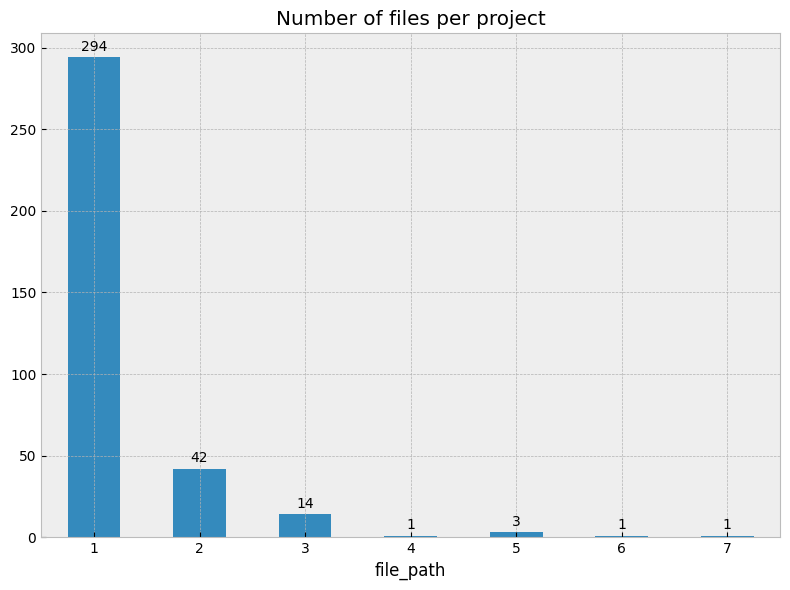

In [7]:
files_per_project = filter_nohelm[[
    'owner', 'project', 'file_path']].drop_duplicates()

files_counts = files_per_project.groupby(['owner', 'project']).count()

files_counts_values = files_counts['file_path'].value_counts().sort_index()

display(files_counts[files_counts['file_path'] == 7])

plt.figure(figsize=(8, 6))

ax = files_counts_values.plot(
    kind='bar', stacked=True, ax=plt.gca())
ax.tick_params(axis="x", rotation=0)
add_labels(plt, files_counts_values.index,
           files_counts_values.values, hpadding=4)
plt.title("Number of files per project")
plt.tight_layout()
plt.show()


Most projects contain only one file with a HPA definition

## HPA versions found

'584'

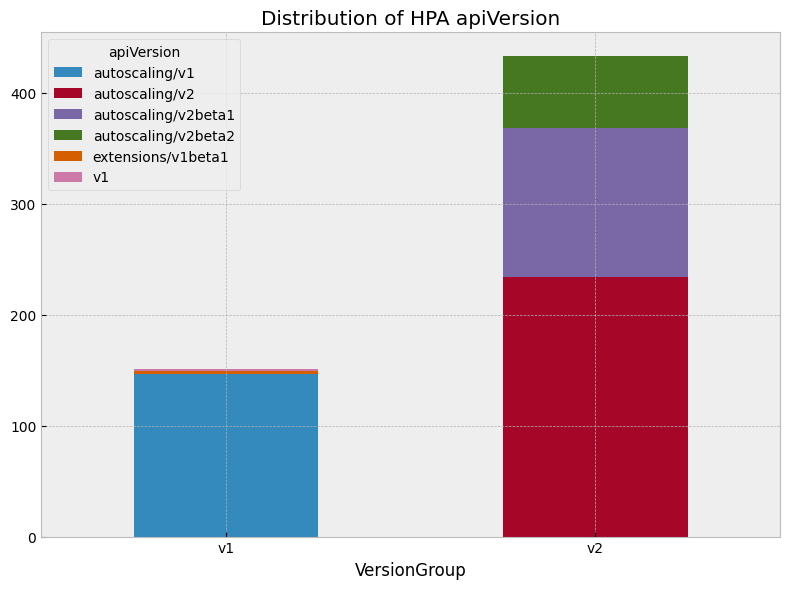

VersionGroup,v1,v2
apiVersion,,
extensions/v1beta1,2.0,0.0
v1,2.0,0.0
autoscaling/v1,147.0,0.0
autoscaling/v2beta2,0.0,65.0
autoscaling/v2beta1,0.0,134.0
autoscaling/v2,0.0,234.0
Total,151.0,433.0


In [8]:
df_hpa_defs = filter_nohelm[[
    'owner', 'project', 'file_path', 'hpa_count', 'apiVersion']].drop_duplicates()

display(f"{df_hpa_defs.shape[0]}")

version_counts = df_hpa_defs['apiVersion'].value_counts().sort_index()
df_grouped = pd.DataFrame(
    {'apiVersion': version_counts.index, 'count': version_counts.values})

df_grouped['VersionGroup'] = df_grouped['apiVersion'].apply(func=map_version)

pivot_versions = df_grouped.pivot(
    index='VersionGroup', columns='apiVersion', values='count').fillna(0)

plt.figure(figsize=(8, 6))
ax = pivot_versions.plot(kind='bar', stacked=True, ax=plt.gca())
# add_labels(plt, pivot_versions.index, pivot_versions.values, hpadding=4)
ax.tick_params(axis="x", rotation=0)
plt.title("Distribution of HPA apiVersion")
plt.tight_layout()
plt.show()

pivot_versions['Total'] = pivot_versions.sum(axis=1)
display(pivot_versions.T.sort_values(['v2', 'v1']))


From the found HPA definitions, circa 26% uses the v1 version, while 74% uses any variations of the v2 version.

## HPA Definitions per file

In some projects, a unique YAML file may have various HPA definitions.

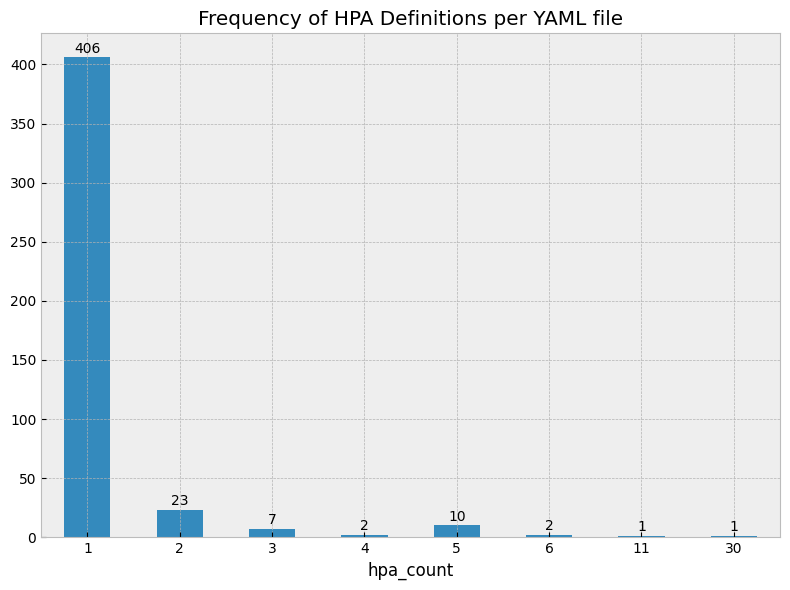

788    search_results/solo-io/service-mesh-for-less-blog/tiered-app/30-namespace-app/ambient/waypoints/hpa-per-namespace.yaml
Name: file_path, dtype: object

402    search_results/vigsachi/erlang/models/online_boutique/mem_autoscale/mem_autoscale_30.yaml
Name: file_path, dtype: object

In [9]:
filter_nohelm_nodups = (
    filter_nohelm
    .sort_values('hpa_count', ascending=False)
    .drop_duplicates(subset=['owner', 'project', 'file_path'], keep='first')
)

hpa_counts = filter_nohelm_nodups['hpa_count'].value_counts().sort_index()
plt.figure(figsize=(8, 6))
ax = hpa_counts.plot(kind='bar')
add_labels(plt, hpa_counts.index, hpa_counts.values, hpadding=4)
ax.tick_params(axis="x", rotation=0)
plt.title("Frequency of HPA Definitions per YAML file")
plt.tight_layout()
plt.show()

display(
    filter_nohelm_nodups[filter_nohelm_nodups['hpa_count'] == 30]['file_path'])
display(
    filter_nohelm_nodups[filter_nohelm_nodups['hpa_count'] == 11]['file_path'])


## Types of Metric per HPA definition

23 HPA definitions present no metrics (they use the default values)


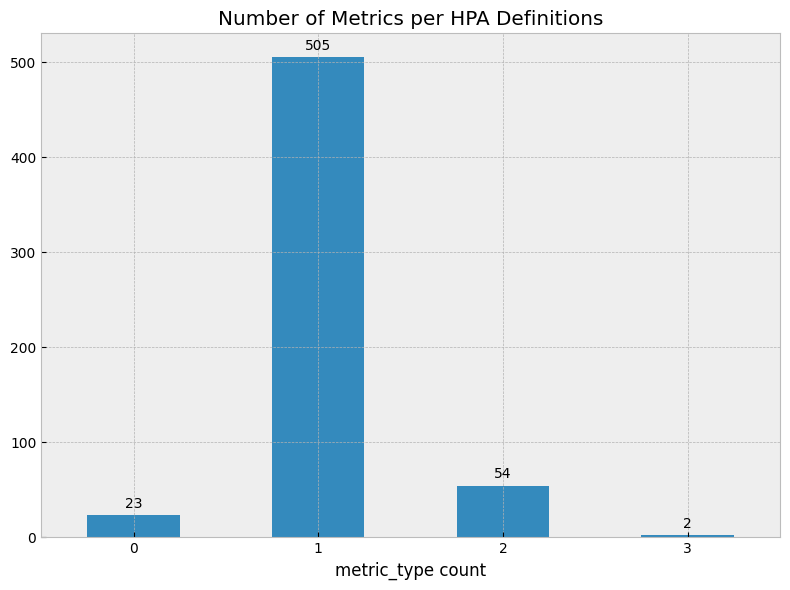

,file_path,metric_type count
57,search_results/JasonMorgan/linkerd-demos/gitops/flux/apps/source/podinfo/patch.yaml,0
100,search_results/ScorpioBroker/ScorpioBroker/KubernetesFile/dist-deployment-files/hpa/registry-subscription-manager.yaml,0
103,search_results/SharadaShehan/Airline_Reservation_System/deploy.yml,0
104,search_results/SharadaShehan/Airline_Reservation_System/deploy.yml,0
105,search_results/SharadaShehan/Airline_Reservation_System/deploy.yml,0
131,search_results/ZenHubHQ/zenhub-enterprise/k8s-cluster/options/scaling/deployments-scaling.yaml,0
132,search_results/ZenHubHQ/zenhub-enterprise/k8s-cluster/options/scaling/deployments-scaling.yaml,0
133,search_results/ZenHubHQ/zenhub-enterprise/k8s-cluster/options/scaling/deployments-scaling.yaml,0
134,search_results/ZenHubHQ/zenhub-enterprise/k8s-cluster/options/scaling/deployments-scaling.yaml,0
135,search_results/ZenHubHQ/zenhub-enterprise/k8s-cluster/options/scaling/deployments-scaling.yaml,0


In [10]:
files_n_def = filter_nohelm[['file_path', 'hpa_count']].drop_duplicates()
# display(files_n_def.shape[0])

metrics_per_def = filter_nohelm.groupby(['file_path', 'hpa_count'])[
    'metric_type'].count().reset_index(name='metric_type count')

zero_metrics = metrics_per_def[metrics_per_def['metric_type count'] == 0]
# display(zero_metrics)
print(
    f"{zero_metrics.shape[0]} HPA definitions present no metrics (they use the default values)")

metrics_counts = metrics_per_def['metric_type count'].value_counts(
).sort_index()

plt.figure(figsize=(8, 6))
ax = metrics_counts.plot(kind='bar')
add_labels(plt, metrics_counts.index, metrics_counts.values, hpadding=8)
ax.tick_params(axis="x", rotation=0)
plt.title("Number of Metrics per HPA Definitions")
plt.tight_layout()
plt.show()

display(metrics_per_def[(metrics_per_def['metric_type count'] == 0) | (
    metrics_per_def['metric_type count'] == 3)][['file_path', 'metric_type count']].sort_values('metric_type count'))


# Types of Metrics

For this step, only the v2 definitions are considered, as v1 contains only CPU and Memory metrics.

491

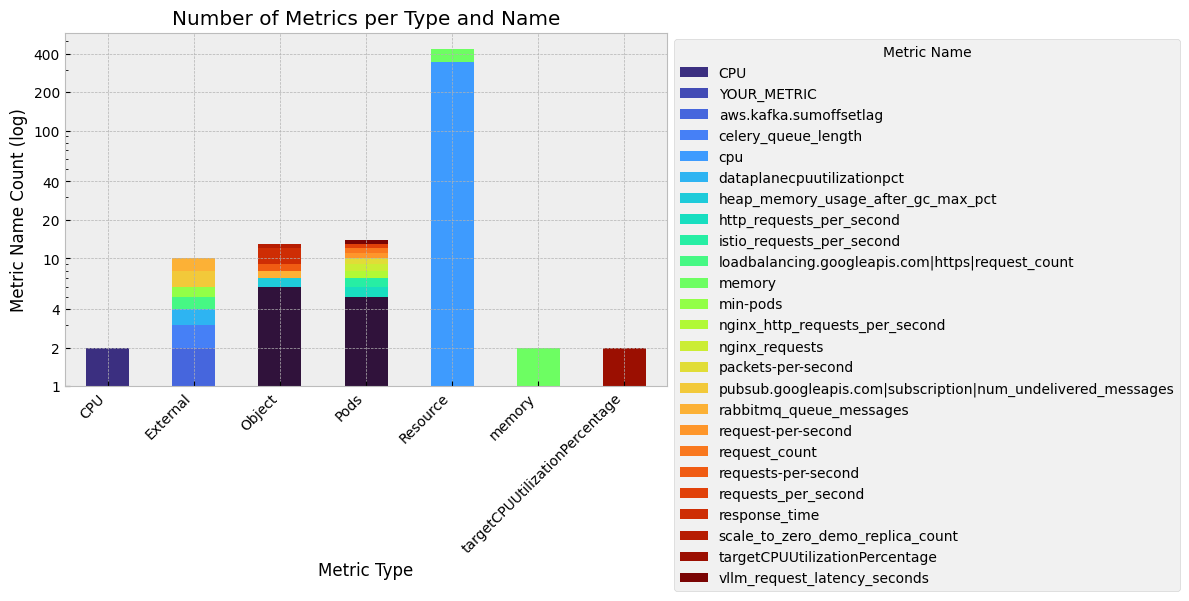

In [11]:
from matplotlib.ticker import LogLocator, FormatStrFormatter
df_v2 = filter_nohelm[filter_nohelm['apiVersion'].str.contains('v2')]
display(df_v2.shape[0])

v2_metrics = df_v2.groupby(
    ['metric_type', 'metric_name']).size().reset_index(name='counts')

pivot_table = v2_metrics.pivot(
    index='metric_type', columns='metric_name', values='counts').fillna(0)


fig = plt.figure(figsize=(12, 6))
pivot_table.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='turbo')
ax = plt.gca()
ax.set_yscale('log')
ax.yaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 4]))
ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))
plt.title('Number of Metrics per Type and Name')
plt.xlabel('Metric Type')
plt.ylabel('Metric Name Count (log)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric Name', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


The Resource Metric Type obfuscate the other types due to its popularity.

Bellow we present the same values, but removing this type and using linear scale.

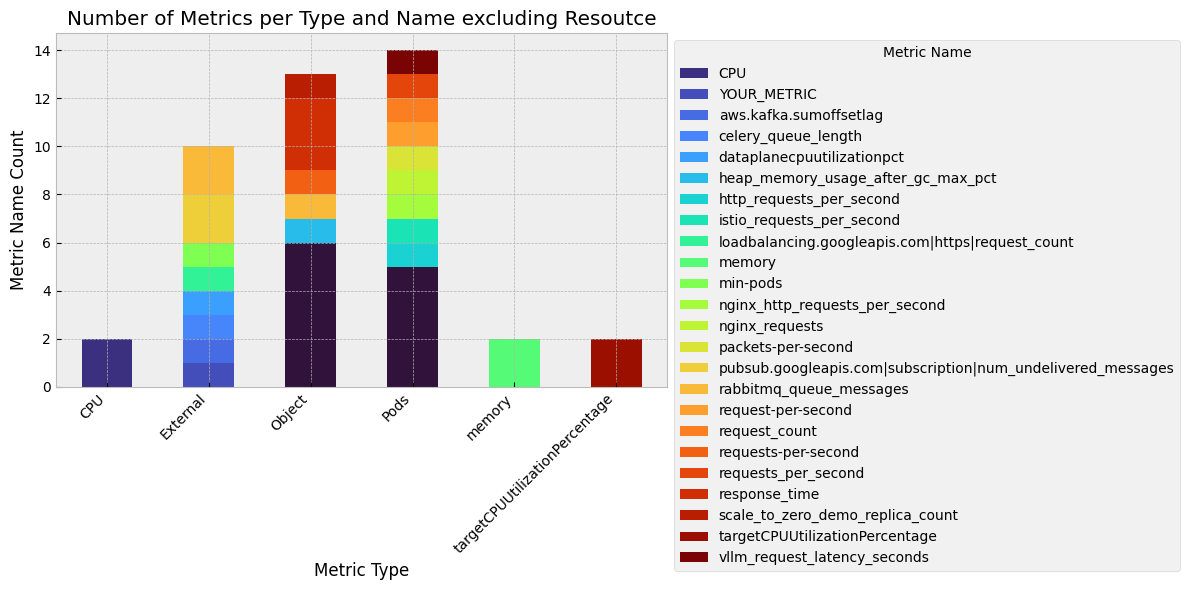

In [12]:
df_v2 = filter_nohelm[filter_nohelm['apiVersion'].str.contains('v2')]

df_v2_no_resource = df_v2[df_v2['metric_type'] != 'Resource']

# display(df_v2_no_resource[df_v2_no_resource['metric_type'] == 'External'])

v2_metrics = df_v2_no_resource.groupby(
    ['metric_type', 'metric_name']).size().reset_index(name='counts')

pivot_table = v2_metrics.pivot(
    index='metric_type', columns='metric_name', values='counts').fillna(0)

plt.figure(figsize=(12, 6))
pivot_table.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='turbo')
plt.title('Number of Metrics per Type and Name excluding Resoutce')
plt.xlabel('Metric Type')
plt.ylabel('Metric Name Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric Name', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


In [13]:
df_v2[df_v2['metric_type'] == "Object"]

,owner,project,file_path,hpa_count,apiVersion,is_helm_template,metric_name,metric_type,target_value,has_behavior
62,arafkarsh,k8s-quickstart,search_results/arafkarsh/k8s-quickstart/colima/Yamls/app/fusion-12-water-product-hpa-green.yaml,1,autoscaling/v2,False,requests-per-second,Object,1k,False
173,nalbam,kubernetes,search_results/nalbam/kubernetes/sample/prometheus-example-app.yaml,1,autoscaling/v2beta1,False,,Object,None,False
269,oracle,coherence-operator,search_results/oracle/coherence-operator/examples/200_autoscaler/manifests/hpa.yaml,1,autoscaling/v2beta2,False,heap_memory_usage_after_gc_max_pct,Object,80000m,True
278,deib-polimi,kosmos,search_results/deib-polimi/kosmos/examples/benchmark/application_khpa/hpa.yaml,1,autoscaling/v2beta2,False,response_time,Object,200m,True
280,deib-polimi,serverless-sock-shop,search_results/deib-polimi/serverless-sock-shop/deploy/sock-shop-openfaas/hpa_rt/user-svc.yaml,1,autoscaling/v2beta2,False,response_time,Object,25m,True
282,deib-polimi,neptune,search_results/deib-polimi/neptune/example/sock-shop-openfaas/hpa_rt/user-svc.yaml,1,autoscaling/v2beta2,False,response_time,Object,25m,True
318,ryan-a-baker,k8s-scaling-demo,search_results/ryan-a-baker/k8s-scaling-demo/charts/rabbitmq-sample-app/templates/hpa.yaml,1,autoscaling/v2beta2,False,rabbitmq_queue_messages,Object,100,False
417,liferight,docker,search_results/liferight/docker/k8s/manifests/HPA/sample-metrics-app.yaml,1,autoscaling/v2beta1,False,,Object,None,False
508,barkbay,k8s-app-lab,search_results/barkbay/k8s-app-lab/java/5-hpa.yaml,1,autoscaling/v2beta1,False,,Object,None,False
740,mitchhh22,k8s-rum-hpa,search_results/mitchhh22/k8s-rum-hpa/hpa/hpa.yml,1,autoscaling/v2beta1,False,,Object,None,False


# Projects and Files Commits

##  Getting Information about the repositories and files commits

In [14]:
config = {
    **os.environ,
    **dotenv_values(".env")
}
github = GhApi(token=config['GITHUB_TOKEN'])


### Repositories Data

In [18]:
wait_for_reset('core')

repos_details = []

with ThreadPoolExecutor(max_workers=16) as pool:
    future = {
        pool.submit(get_repo_details, row): idx
        for idx, row in filter_nohelm_nodups.iterrows()
    }

    for fut in as_completed(future):
        repos_details.append(fut.result())

In [19]:
df_details = pd.concat(repos_details)
display(df_details)


,stargazers_count,created_at,pushed_at
1012,8,2022-04-18T00:04:54Z,2025-04-12T02:40:20Z
1253,17,2018-11-15T05:08:53Z,2019-01-23T05:09:48Z
911,13,2018-11-19T20:50:29Z,2018-12-13T20:43:51Z
1299,4,2019-12-04T08:45:11Z,2023-01-27T01:10:39Z
1289,5,2018-12-06T04:00:11Z,2018-12-15T04:45:44Z
...,...,...,...
1442,2,2023-06-18T03:31:13Z,2023-06-15T01:18:44Z
35,87,2018-07-31T07:45:33Z,2024-10-06T00:14:40Z
1441,2,2023-06-18T03:31:13Z,2023-06-15T01:18:44Z
26,172,2017-12-20T03:17:07Z,2018-09-24T12:10:08Z


### Commit Data from the YAML Files

In [20]:
wait_for_reset('core')

paths_committed_at = []

with ThreadPoolExecutor(max_workers=16) as pool:
    future = {
        pool.submit(get_file_first_last_commit, row): idx
        for idx, row in filter_nohelm_nodups.iterrows()
    }

    for fut in as_completed(future):
        paths_committed_at.append(fut.result())


# paths_committed_at = [get_file_first_last_commit(row) for _, row in filter_nohelm_nodups.iterrows()]


In [22]:
df_committed_at = pd.concat(paths_committed_at)
display(df_committed_at)


,file_first_commit,file_last_commit
911,2018-11-20T01:01:13Z,2018-12-07T22:10:41Z
402,2024-03-02T23:11:40Z,2024-03-02T23:11:40Z
409,2018-11-16T16:40:53Z,2018-11-16T16:40:53Z
1012,2022-12-13T07:04:55Z,2022-12-13T07:04:55Z
1282,2023-11-30T02:51:53Z,2023-11-30T02:51:53Z
...,...,...
1454,2020-04-13T09:26:41Z,2020-04-13T09:26:41Z
1442,2023-01-04T04:41:03Z,2023-01-04T04:41:03Z
1441,2022-12-30T23:49:49Z,2022-12-30T23:49:49Z
35,2019-12-25T12:57:00Z,2019-12-25T12:57:00Z


### Join the new data to filter_nohelm in a new DataFrame

In [23]:
items_details = filter_nohelm_nodups.join([df_details, df_committed_at])

display(items_details)


,owner,project,file_path,hpa_count,apiVersion,is_helm_template,metric_name,metric_type,target_value,has_behavior,stargazers_count,created_at,pushed_at,file_first_commit,file_last_commit
788,solo-io,service-mesh-for-less-blog,search_results/solo-io/service-mesh-for-less-blog/tiered-app/30-namespace-app/ambient/waypoints/hpa-per-namespace.yaml,30,autoscaling/v2,False,cpu,Resource,80,False,3,2024-03-14T00:05:33Z,2024-06-24T16:23:15Z,2024-03-19T19:28:50Z,2024-05-15T20:20:52Z
402,vigsachi,erlang,search_results/vigsachi/erlang/models/online_boutique/mem_autoscale/mem_autoscale_30.yaml,11,autoscaling/v2beta1,False,memory,Resource,None,False,7,2024-03-02T23:08:27Z,2024-11-11T00:24:46Z,2024-03-02T23:11:40Z,2024-03-02T23:11:40Z
1282,shaohaiyang,easyKubernetes,search_results/shaohaiyang/easyKubernetes/samples/knative/istio.yaml,6,autoscaling/v2beta1,False,cpu,Resource,None,False,6,2018-05-27T03:24:33Z,2023-11-30T02:52:04Z,2023-11-30T02:51:53Z,2023-11-30T02:51:53Z
1012,Young-ook,terraform-aws-fis,search_results/Young-ook/terraform-aws-fis/examples/blueprint/apps/sockshop/sockshop-demo-hpa.yaml,6,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,50,False,8,2022-04-18T00:04:54Z,2025-04-12T02:40:20Z,2022-12-13T07:04:55Z,2022-12-13T07:04:55Z
1299,nikkkkhil,tensorRT-NVIDIA,search_results/nikkkkhil/tensorRT-NVIDIA/examples/90_Kubernetes/istio/rendered/istio-v1.0-minikube.yml,5,autoscaling/v2beta1,False,cpu,Resource,None,False,4,2019-12-04T08:45:11Z,2023-01-27T01:10:39Z,2019-12-04T08:45:20Z,2019-12-04T08:45:20Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,callmer00t,kubeguide_example,search_results/callmer00t/kubeguide_example/Chapter_3/php-apache-hpa-v1.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,50,False,19,2020-04-04T13:43:13Z,2021-04-04T01:56:57Z,2020-04-13T09:26:41Z,2020-04-13T09:26:41Z
1442,arunvel1988,ANTON,search_results/arunvel1988/ANTON/lessons/143/istiod/autoscale.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,2,2023-06-18T03:31:13Z,2023-06-15T01:18:44Z,2023-01-04T04:41:03Z,2023-01-04T04:41:03Z
1441,arunvel1988,ANTON,search_results/arunvel1988/ANTON/lessons/142/istiod/autoscale.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,2,2023-06-18T03:31:13Z,2023-06-15T01:18:44Z,2022-12-30T23:49:49Z,2022-12-30T23:49:49Z
35,arisu1000,kubernetes-book-sample,search_results/arisu1000/kubernetes-book-sample/autoscaling/autoscaling.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,30,False,87,2018-07-31T07:45:33Z,2024-10-06T00:14:40Z,2019-12-25T12:57:00Z,2019-12-25T12:57:00Z


## Saves the complete data to CSV file (Phase 4)

In [24]:
items_details.to_csv(
    f"partial_results/{datetime.now().replace(microsecond=0).isoformat()}-phase4.csv", index=False)


## Loads the lastest Phase 4 CSV File

In [25]:
items_details = phase4_files = utils.load_phase4_results()

items_details['created_at'] = pd.to_datetime(items_details['created_at'])
items_details['pushed_at'] = pd.to_datetime(items_details['pushed_at'])
items_details['file_first_commit'] = pd.to_datetime(
    items_details['file_first_commit'])
items_details['file_last_commit'] = pd.to_datetime(
    items_details['file_last_commit'])

display(items_details)

,owner,project,file_path,hpa_count,apiVersion,is_helm_template,metric_name,metric_type,target_value,has_behavior,stargazers_count,created_at,pushed_at,file_first_commit,file_last_commit
0,solo-io,service-mesh-for-less-blog,search_results/solo-io/service-mesh-for-less-blog/tiered-app/30-namespace-app/ambient/waypoints/hpa-per-namespace.yaml,30,autoscaling/v2,False,cpu,Resource,80,False,3,2024-03-14 00:05:33+00:00,2024-06-24 16:23:15+00:00,2024-03-19 19:28:50+00:00,2024-05-15 20:20:52+00:00
1,vigsachi,erlang,search_results/vigsachi/erlang/models/online_boutique/mem_autoscale/mem_autoscale_30.yaml,11,autoscaling/v2beta1,False,memory,Resource,NaN,False,7,2024-03-02 23:08:27+00:00,2024-11-11 00:24:46+00:00,2024-03-02 23:11:40+00:00,2024-03-02 23:11:40+00:00
2,shaohaiyang,easyKubernetes,search_results/shaohaiyang/easyKubernetes/samples/knative/istio.yaml,6,autoscaling/v2beta1,False,cpu,Resource,NaN,False,6,2018-05-27 03:24:33+00:00,2023-11-30 02:52:04+00:00,2023-11-30 02:51:53+00:00,2023-11-30 02:51:53+00:00
3,Young-ook,terraform-aws-fis,search_results/Young-ook/terraform-aws-fis/examples/blueprint/apps/sockshop/sockshop-demo-hpa.yaml,6,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,50,False,8,2022-04-18 00:04:54+00:00,2025-04-12 02:40:20+00:00,2022-12-13 07:04:55+00:00,2022-12-13 07:04:55+00:00
4,nikkkkhil,tensorRT-NVIDIA,search_results/nikkkkhil/tensorRT-NVIDIA/examples/90_Kubernetes/istio/rendered/istio-v1.0-minikube.yml,5,autoscaling/v2beta1,False,cpu,Resource,NaN,False,4,2019-12-04 08:45:11+00:00,2023-01-27 01:10:39+00:00,2019-12-04 08:45:20+00:00,2019-12-04 08:45:20+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,callmer00t,kubeguide_example,search_results/callmer00t/kubeguide_example/Chapter_3/php-apache-hpa-v1.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,50,False,19,2020-04-04 13:43:13+00:00,2021-04-04 01:56:57+00:00,2020-04-13 09:26:41+00:00,2020-04-13 09:26:41+00:00
448,arunvel1988,ANTON,search_results/arunvel1988/ANTON/lessons/143/istiod/autoscale.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,2,2023-06-18 03:31:13+00:00,2023-06-15 01:18:44+00:00,2023-01-04 04:41:03+00:00,2023-01-04 04:41:03+00:00
449,arunvel1988,ANTON,search_results/arunvel1988/ANTON/lessons/142/istiod/autoscale.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,2,2023-06-18 03:31:13+00:00,2023-06-15 01:18:44+00:00,2022-12-30 23:49:49+00:00,2022-12-30 23:49:49+00:00
450,arisu1000,kubernetes-book-sample,search_results/arisu1000/kubernetes-book-sample/autoscaling/autoscaling.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,30,False,87,2018-07-31 07:45:33+00:00,2024-10-06 00:14:40+00:00,2019-12-25 12:57:00+00:00,2019-12-25 12:57:00+00:00


## HPA versions release dates

In [26]:
releasedate_hpav1 = pd.to_datetime("2016-10-25").replace(tzinfo=None)
releasedate_hpav2beta1 = pd.to_datetime("2017-09-28").replace(tzinfo=None)
releasedate_hpav2beta2 = pd.to_datetime("2018-09-25").replace(tzinfo=None)
releasedate_hpav2 = pd.to_datetime("2021-12-07").replace(tzinfo=None)


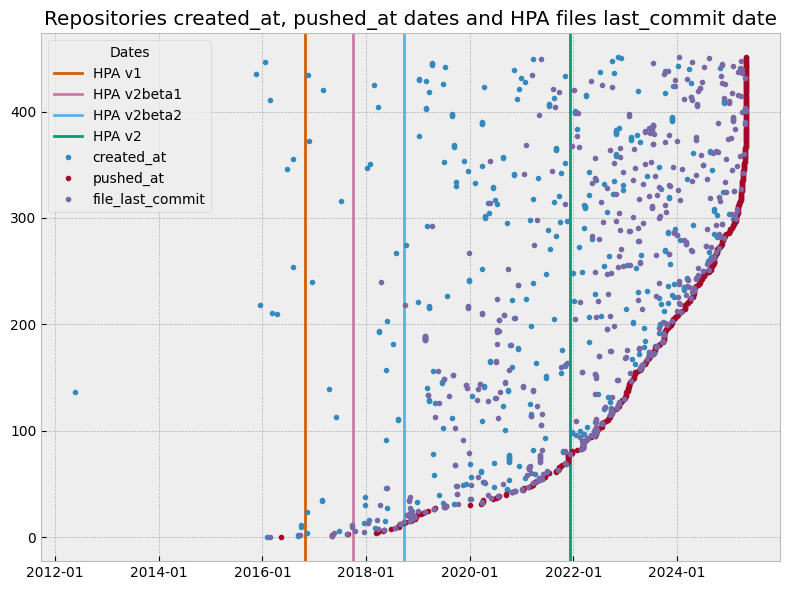

In [27]:
def dates_scatter_plot(df):
    plt.figure(figsize=(8, 6))

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    plt.axvline(x=releasedate_hpav1, color=colors[4], label="HPA v1")
    plt.axvline(x=releasedate_hpav2beta1, color=colors[5], label="HPA v2beta1")
    plt.axvline(x=releasedate_hpav2beta2, color=colors[6], label="HPA v2beta2")
    plt.axvline(x=releasedate_hpav2, color=colors[7], label="HPA v2")

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

    plt.plot(df['created_at'], df.index,
             marker='.', linestyle='', label='created_at')
    plt.plot(df['pushed_at'], df.index,
             marker='.', linestyle='', label='pushed_at')
    plt.plot(df['file_last_commit'], df.index,
             marker='.', linestyle='', label='file_last_commit')

    plt.legend(title='Dates')
    plt.title("Repositories created_at, pushed_at dates and HPA files last_commit date")
    plt.tight_layout()
    plt.show()


dates_scatter_plot(items_details.sort_values('pushed_at', ignore_index=True))


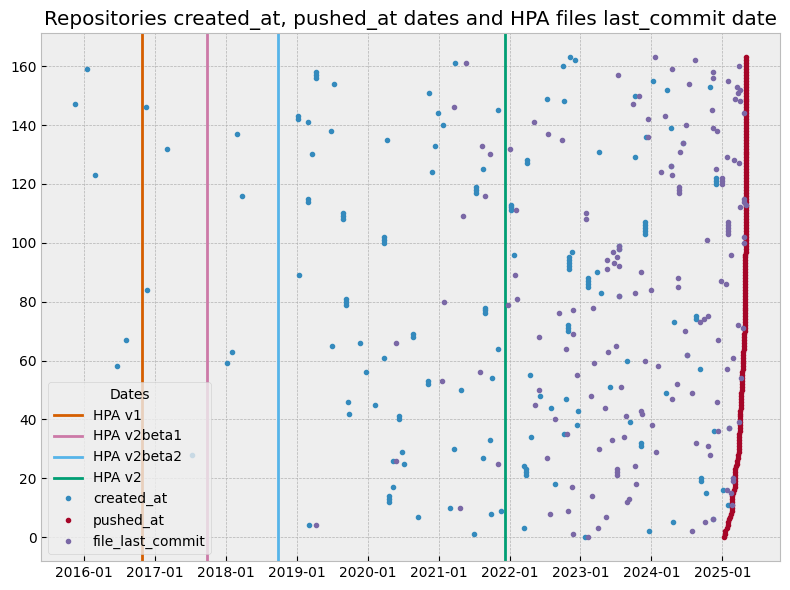

In [28]:
dates_scatter_plot(items_details[items_details['pushed_at'] > '2025-01-01'].sort_values(
    'pushed_at', ignore_index=True))


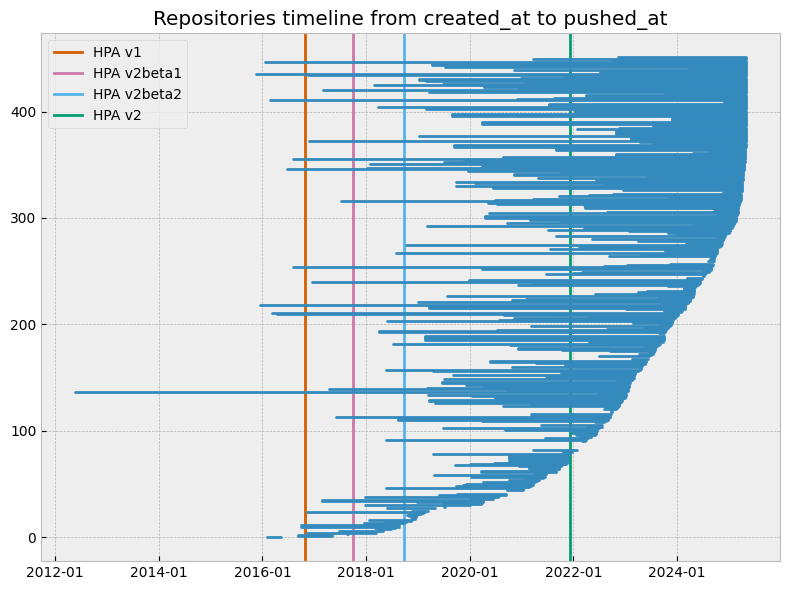

In [30]:
def timeline_plot(df):
    plt.figure(figsize=(8, 6))
    num_rows = df.shape[0]

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    oldest_file_at = df['created_at'].sort_values(inplace=False).iloc[0]
    if releasedate_hpav1 > oldest_file_at.replace(tzinfo=None):
        plt.axvline(x=releasedate_hpav1, color=colors[4], label="HPA v1")
    plt.axvline(x=releasedate_hpav2beta1, color=colors[5], label="HPA v2beta1")
    plt.axvline(x=releasedate_hpav2beta2, color=colors[6], label="HPA v2beta2")
    plt.axvline(x=releasedate_hpav2, color=colors[7], label="HPA v2")

    for i in df.index:
        x1 = df.loc[i, 'created_at']
        x2 = df.loc[i, 'pushed_at']
        normalized_i = i / (num_rows - 1) if num_rows > 1 else 0.5
        plt.plot([x1, x2], [i, i], linewidth=2,
                 color=colors[0], solid_capstyle='round')

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.title("Repositories timeline from created_at to pushed_at")
    plt.legend()
    plt.tight_layout()
    plt.show()


timeline_plot(items_details.sort_values('pushed_at', ignore_index=True))


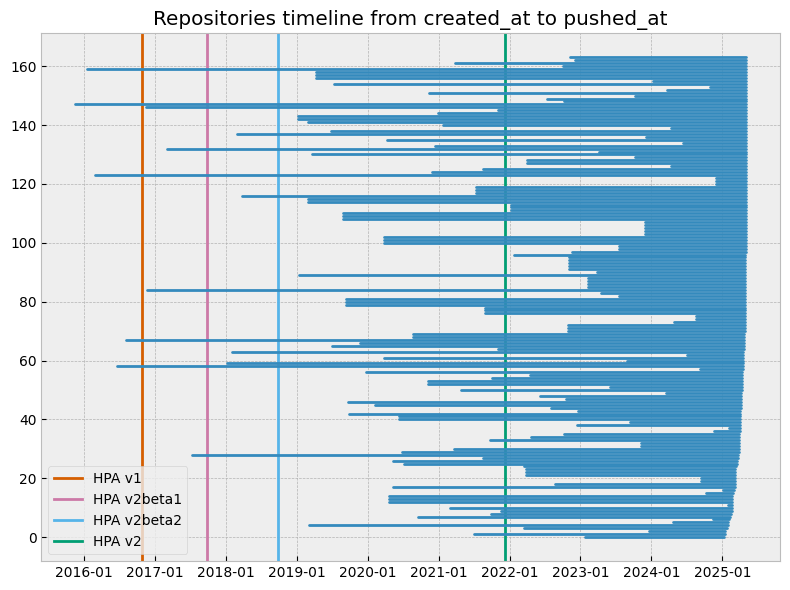

In [31]:
timeline_plot(items_details[items_details['pushed_at'] >
              '2025-01-01'].sort_values('pushed_at', ignore_index=True))


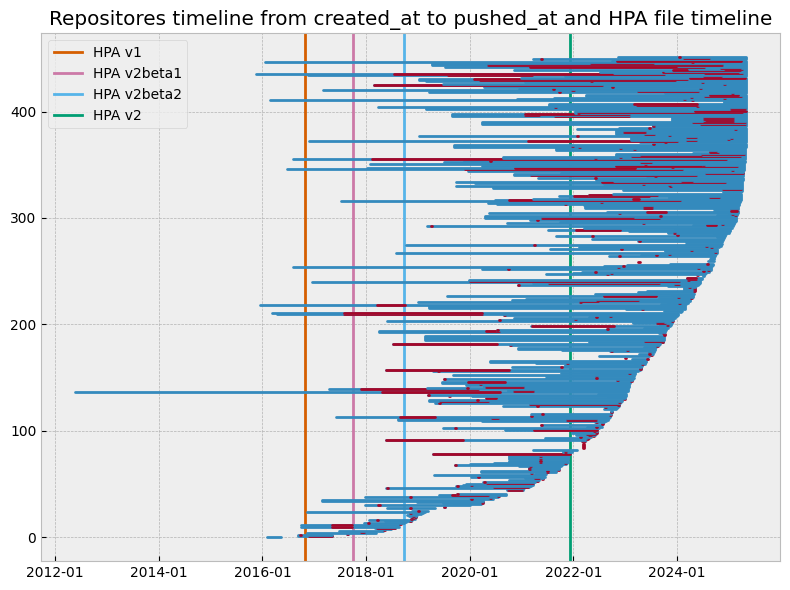

In [35]:
def repo_timeline_plot(df):
    fig, ax = plt.subplots(figsize=(8, 6))

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    oldest_time = df['created_at'].sort_values(inplace=False).iloc[0]

    if releasedate_hpav1 > oldest_time.replace(tzinfo=None):
        plt.axvline(x=releasedate_hpav1, color=colors[4], label="HPA v1")
    if releasedate_hpav1 > oldest_time.replace(tzinfo=None):
        plt.axvline(x=releasedate_hpav2beta1, color=colors[5], label="HPA v2beta1")
    if releasedate_hpav1 > oldest_time.replace(tzinfo=None):
        plt.axvline(x=releasedate_hpav2beta2, color=colors[6], label="HPA v2beta2")
    plt.axvline(x=releasedate_hpav2, color=colors[7], label="HPA v2")

    for i in range(df.shape[0]):
        x1 = mdates.date2num(df.iloc[i]['created_at'])
        x2 = mdates.date2num(df.iloc[i]['pushed_at'])
        plt.plot(
            [x1, x2],
            [i, i],
            linewidth='2',
            solid_capstyle='round',
            color=colors[0]
        )

        x3 = mdates.date2num(df.iloc[i]['file_first_commit'])
        x4 = mdates.date2num(df.iloc[i]['file_last_commit'])
        # when tere's only one commit, adds a minimal value for graph exibition
        if x3 == x4:
            x4 = x4 + 5

        plt.plot(
            [x3, x4],
            [i, i],
            linewidth='2',
            solid_capstyle='round',
            color=colors[1]
        )

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    plt.legend(loc='upper left')

    plt.title("Repositores timeline from created_at to pushed_at and HPA file timeline")
    plt.tight_layout()
    plt.show()


repo_timeline_plot(items_details.sort_values('pushed_at', ignore_index=True))


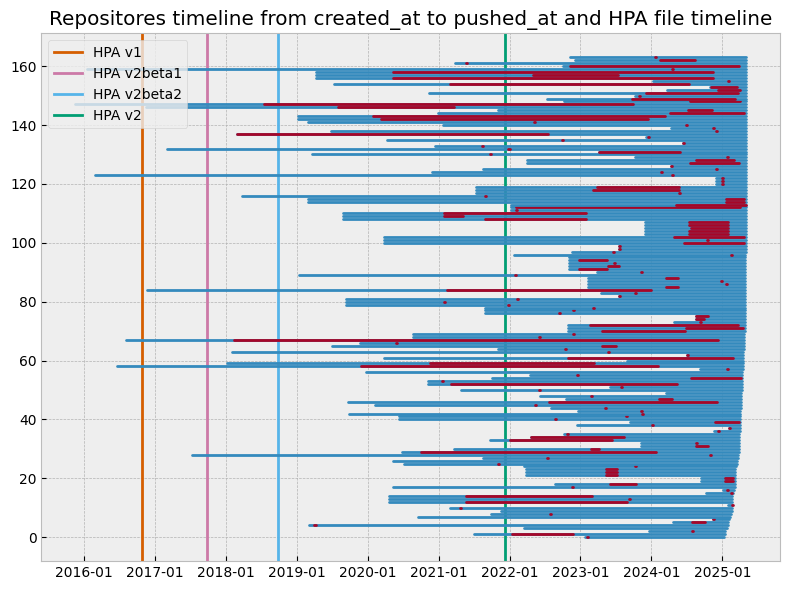

In [36]:
repo_timeline_plot(items_details[items_details['pushed_at'] > '2025-01-01'].sort_values('pushed_at', ignore_index=True))

In [37]:
items_details[items_details['owner'] == 'GoogleCloudPlatform']


,owner,project,file_path,hpa_count,apiVersion,is_helm_template,metric_name,metric_type,target_value,has_behavior,stargazers_count,created_at,pushed_at,file_first_commit,file_last_commit
331,GoogleCloudPlatform,cloud-builders,search_results/GoogleCloudPlatform/cloud-builders/gke-deploy/deployer/testing/expected-suggested/no-config.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,1396,2016-06-21 17:01:33+00:00,2025-04-16 19:28:53+00:00,2019-11-25 16:56:21+00:00,2024-02-02 20:44:49+00:00
332,GoogleCloudPlatform,click-to-deploy-solutions,search_results/GoogleCloudPlatform/click-to-deploy-solutions/gke-autopilot-hpa/build/hpa-example.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,50,False,96,2022-12-16 18:26:08+00:00,2025-03-31 10:43:21+00:00,2024-01-06 16:46:28+00:00,2024-01-06 16:46:28+00:00
333,GoogleCloudPlatform,apigee-anthos-service-mesh-demo,search_results/GoogleCloudPlatform/apigee-anthos-service-mesh-demo/api-ingress/kubernetes-manifests/deployment.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,39,2022-04-20 00:11:55+00:00,2025-03-28 22:43:36+00:00,2022-04-22 19:23:17+00:00,2023-08-14 21:45:18+00:00
334,GoogleCloudPlatform,anthos-service-mesh-packages,search_results/GoogleCloudPlatform/anthos-service-mesh-packages/samples/gateways/istio-egressgateway/autoscaling-v2beta1.yaml,1,autoscaling/v2beta1,False,cpu,Resource,NaN,False,136,2020-02-06 18:07:31+00:00,2025-04-04 07:41:14+00:00,2022-05-09 23:39:10+00:00,2022-05-09 23:39:10+00:00
335,GoogleCloudPlatform,anthos-service-mesh-samples,search_results/GoogleCloudPlatform/anthos-service-mesh-samples/docs/ingress-gateway-external-lb/ingress-gateway-nonroot.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,42,2020-06-10 17:07:29+00:00,2025-04-01 03:02:53+00:00,2023-08-25 15:29:53+00:00,2023-08-25 15:29:53+00:00
336,GoogleCloudPlatform,anthos-service-mesh-samples,search_results/GoogleCloudPlatform/anthos-service-mesh-samples/docs/ingress-gateway-external-lb/ingress-gateway.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,42,2020-06-10 17:07:29+00:00,2025-04-01 03:02:53+00:00,2022-08-22 21:30:20+00:00,2022-08-22 21:30:20+00:00
337,GoogleCloudPlatform,k8s-config-connector,search_results/GoogleCloudPlatform/k8s-config-connector/install-bundles/install-bundle-gcp-identity/0-cnrm-system.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,70,False,955,2019-04-08 07:41:30+00:00,2025-05-04 06:51:58+00:00,2020-05-11 16:39:12+00:00,2024-11-13 02:23:13+00:00
338,GoogleCloudPlatform,k8s-config-connector,search_results/GoogleCloudPlatform/k8s-config-connector/install-bundles/install-bundle-workload-identity/0-cnrm-system.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,70,False,955,2019-04-08 07:41:30+00:00,2025-05-04 06:51:58+00:00,2020-05-11 16:39:12+00:00,2024-11-13 02:23:13+00:00
339,GoogleCloudPlatform,k8s-config-connector,search_results/GoogleCloudPlatform/k8s-config-connector/config/installbundle/components/webhook/autoscaler.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,70,False,955,2019-04-08 07:41:30+00:00,2025-05-04 06:51:58+00:00,2022-05-03 01:36:58+00:00,2023-07-13 20:49:51+00:00
363,GoogleCloudPlatform,cloud-learning-platform,search_results/GoogleCloudPlatform/cloud-learning-platform/microservices/student_learner_profile/kustomize/prod/hpa.yaml,1,autoscaling/v2,False,cpu,Resource,60,False,34,2022-10-31 14:04:20+00:00,2025-04-29 16:48:10+00:00,2023-05-23 10:54:25+00:00,2023-07-20 10:26:39+00:00


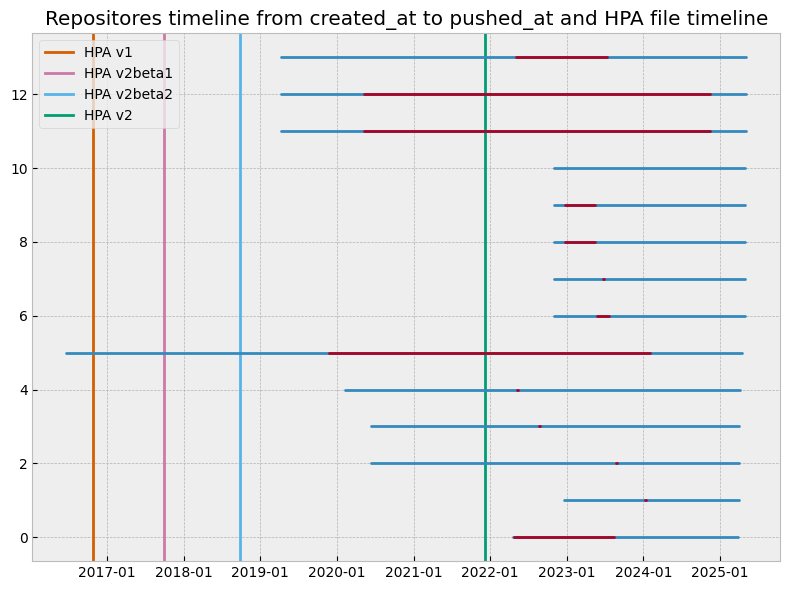

In [41]:
repo_timeline_plot(items_details[items_details['owner'] == 'GoogleCloudPlatform'].sort_values('pushed_at', ignore_index=True))

In [42]:
items_details[items_details['pushed_at'] > '2025-01-01'].shape[0]


164

# download HPA file history for comparison

In [46]:
display(items_details.iloc[331:339])


,owner,project,file_path,hpa_count,apiVersion,is_helm_template,metric_name,metric_type,target_value,has_behavior,stargazers_count,created_at,pushed_at,file_first_commit,file_last_commit
331,GoogleCloudPlatform,cloud-builders,search_results/GoogleCloudPlatform/cloud-builders/gke-deploy/deployer/testing/expected-suggested/no-config.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,1396,2016-06-21 17:01:33+00:00,2025-04-16 19:28:53+00:00,2019-11-25 16:56:21+00:00,2024-02-02 20:44:49+00:00
332,GoogleCloudPlatform,click-to-deploy-solutions,search_results/GoogleCloudPlatform/click-to-deploy-solutions/gke-autopilot-hpa/build/hpa-example.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,50,False,96,2022-12-16 18:26:08+00:00,2025-03-31 10:43:21+00:00,2024-01-06 16:46:28+00:00,2024-01-06 16:46:28+00:00
333,GoogleCloudPlatform,apigee-anthos-service-mesh-demo,search_results/GoogleCloudPlatform/apigee-anthos-service-mesh-demo/api-ingress/kubernetes-manifests/deployment.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,39,2022-04-20 00:11:55+00:00,2025-03-28 22:43:36+00:00,2022-04-22 19:23:17+00:00,2023-08-14 21:45:18+00:00
334,GoogleCloudPlatform,anthos-service-mesh-packages,search_results/GoogleCloudPlatform/anthos-service-mesh-packages/samples/gateways/istio-egressgateway/autoscaling-v2beta1.yaml,1,autoscaling/v2beta1,False,cpu,Resource,NaN,False,136,2020-02-06 18:07:31+00:00,2025-04-04 07:41:14+00:00,2022-05-09 23:39:10+00:00,2022-05-09 23:39:10+00:00
335,GoogleCloudPlatform,anthos-service-mesh-samples,search_results/GoogleCloudPlatform/anthos-service-mesh-samples/docs/ingress-gateway-external-lb/ingress-gateway-nonroot.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,42,2020-06-10 17:07:29+00:00,2025-04-01 03:02:53+00:00,2023-08-25 15:29:53+00:00,2023-08-25 15:29:53+00:00
336,GoogleCloudPlatform,anthos-service-mesh-samples,search_results/GoogleCloudPlatform/anthos-service-mesh-samples/docs/ingress-gateway-external-lb/ingress-gateway.yaml,1,autoscaling/v2,False,cpu,Resource,80,False,42,2020-06-10 17:07:29+00:00,2025-04-01 03:02:53+00:00,2022-08-22 21:30:20+00:00,2022-08-22 21:30:20+00:00
337,GoogleCloudPlatform,k8s-config-connector,search_results/GoogleCloudPlatform/k8s-config-connector/install-bundles/install-bundle-gcp-identity/0-cnrm-system.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,70,False,955,2019-04-08 07:41:30+00:00,2025-05-04 06:51:58+00:00,2020-05-11 16:39:12+00:00,2024-11-13 02:23:13+00:00
338,GoogleCloudPlatform,k8s-config-connector,search_results/GoogleCloudPlatform/k8s-config-connector/install-bundles/install-bundle-workload-identity/0-cnrm-system.yaml,1,autoscaling/v1,False,targetCPUUtilizationPercentage,targetCPUUtilizationPercentage,70,False,955,2019-04-08 07:41:30+00:00,2025-05-04 06:51:58+00:00,2020-05-11 16:39:12+00:00,2024-11-13 02:23:13+00:00


In [47]:
display(download_file_history(items_details.iloc[338]))


found 140 commits


None

In [49]:
display(download_file_history(items_details.iloc[331]))

found 3 commits


None

## Previous HPA Versions of a File

2020-01-28T17:59:44Z autoscaling/v2beta1
18289.749814814815
2019-11-25T16:56:21Z autoscaling/v2beta1
18225.70579861111
2024-02-02T20:44:49Z autoscaling/v2
19755.86445601852


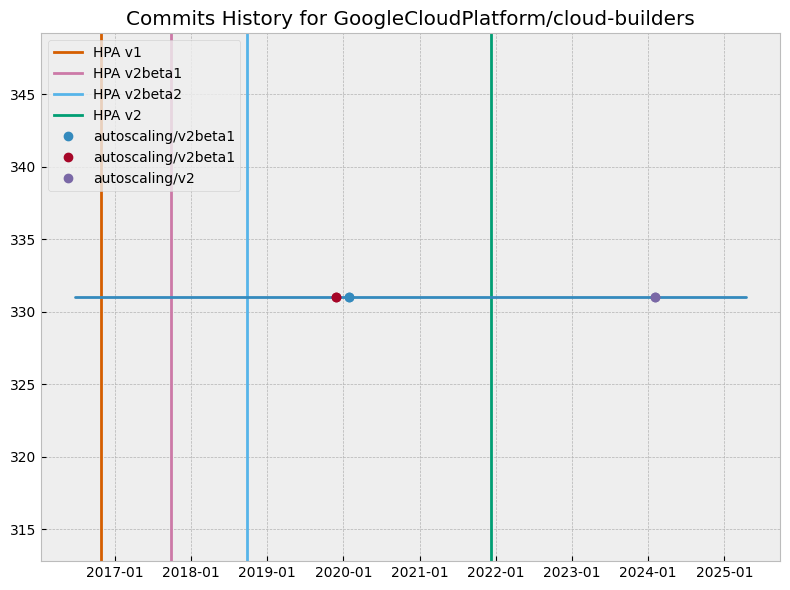

In [55]:
def get_apiversion_history(row):
    root_dir = 'repos_history'
    repo_path = Path(root_dir, row['owner'], row['project'])

    hpa_commits = {}
    for dirpath, dirnames, filenames in os.walk(f"{repo_path}"):
        for filename in filenames:
            file_path = Path(dirpath, filename)
            commit_path = Path(dirpath).relative_to(repo_path).parts[0]

            hpa_definitions = process_yaml_file(file_path)
            if (len(hpa_definitions) > 0):
                hpa_commits[commit_path] = hpa_definitions[0]['apiVersion']
    
    fig, ax = plt.subplots(figsize=(8, 6))

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    if releasedate_hpav1 > pd.to_datetime(row['created_at']).replace(tzinfo=None):
        plt.axvline(x=releasedate_hpav1, color=colors[4], label="HPA v1")
    if releasedate_hpav1 > pd.to_datetime(row['created_at']).replace(tzinfo=None):
        plt.axvline(x=releasedate_hpav2beta1, color=colors[5], label="HPA v2beta1")
    if releasedate_hpav1 > pd.to_datetime(row['created_at']).replace(tzinfo=None):
        plt.axvline(x=releasedate_hpav2beta2, color=colors[6], label="HPA v2beta2")
    plt.axvline(x=releasedate_hpav2, color=colors[7], label="HPA v2")

    x1 = mdates.date2num(row['created_at'])
    x2 = mdates.date2num(row['pushed_at'])
    plt.plot(
        [x1, x2],
        [row.name, row.name],
        linewidth='2',
        solid_capstyle='round',
        color=colors[0]
    )

    for date, version in hpa_commits.items():
        print(date, version)
        x = mdates.datestr2num(date)
        print(x)
        plt.plot(
            [x, x],
            [row.name, row.name],
            linewidth='0',
            marker='o',
            label=version
        )

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    plt.title(f"Commits History for {row['owner']}/{row['project']}")

    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

get_apiversion_history(items_details.iloc[331])


2021-06-24T23:21:56Z autoscaling/v2beta2
18802.973564814816
2022-01-06T22:19:38Z autoscaling/v2beta2
18998.930300925927
2021-04-06T18:31:32Z autoscaling/v2beta2
18723.77189814815
2022-05-09T23:02:18Z autoscaling/v2beta2
19121.959930555557
2020-10-28T21:15:18Z autoscaling/v2beta2
18563.885625
2021-07-31T04:54:54Z autoscaling/v2beta2
18839.204791666667
2022-08-04T05:11:13Z autoscaling/v2beta2
19208.216122685186
2022-04-06T14:43:42Z autoscaling/v2beta2
19088.613680555554
2024-01-23T22:28:47Z autoscaling/v1
19745.93665509259
2022-03-30T22:28:29Z autoscaling/v2beta2
19081.93644675926
2024-08-03T01:53:32Z autoscaling/v1
19938.078842592593
2023-02-22T19:09:52Z autoscaling/v1
19410.798518518517
2021-05-04T23:45:36Z autoscaling/v2beta2
18751.99
2021-07-12T22:20:03Z autoscaling/v2beta2
18820.930590277778
2022-02-17T20:15:53Z autoscaling/v2beta2
19040.844363425927
2022-02-02T20:20:36Z autoscaling/v2beta2
19025.84763888889
2023-09-27T20:14:13Z autoscaling/v1
19627.84320601852
2021-10-21T19:52:51Z 

/tmp/ipykernel_37994/1704095913.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


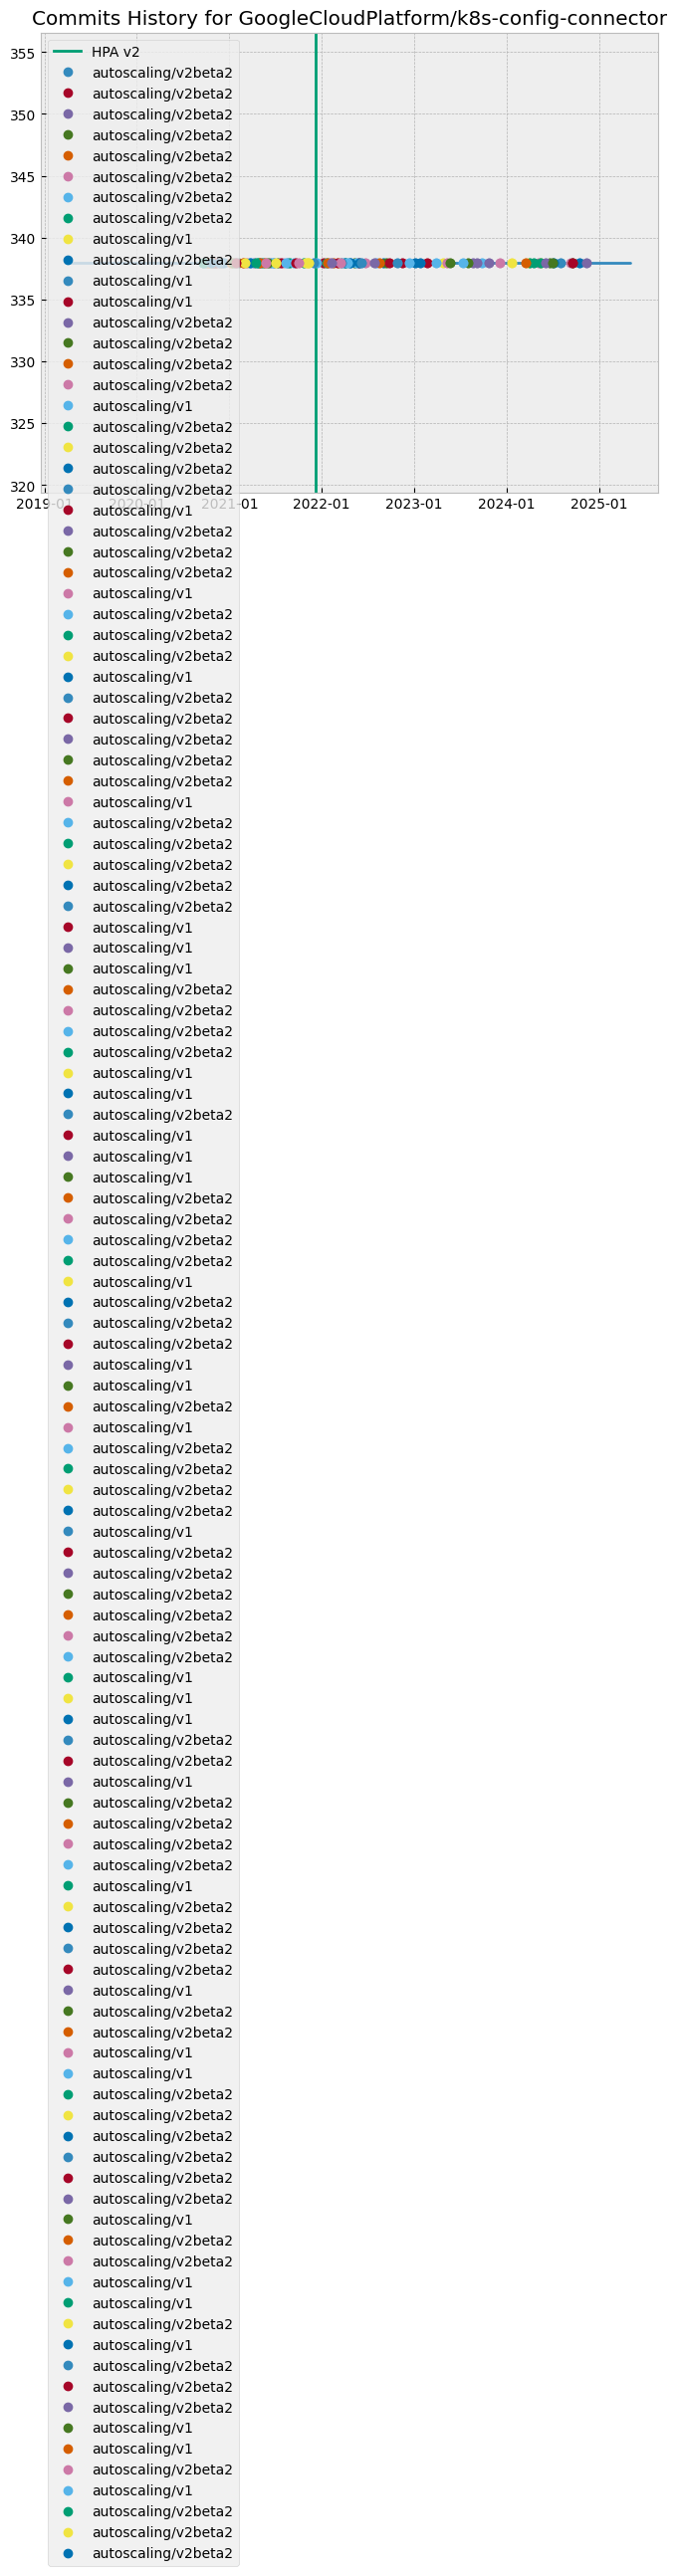

In [57]:
get_apiversion_history(items_details.iloc[338])